
--- TOP 10 HARDWARE/SOFTWARE ISSUES ---
           Phrase  Frequency  Severity
0    battery life          9  0.027078
1     blue screen          6 -0.207567
2       hot touch          5 -0.060640
3  windows update          3 -0.036000
4    black screen          2 -0.675500
5    touch screen          2 -0.317750
6     update bios          2 -0.530900


/var/folders/xc/7907wjlx0h93vk1t9120tn9w0000gn/T/ipykernel_46220/1877694301.py:167: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


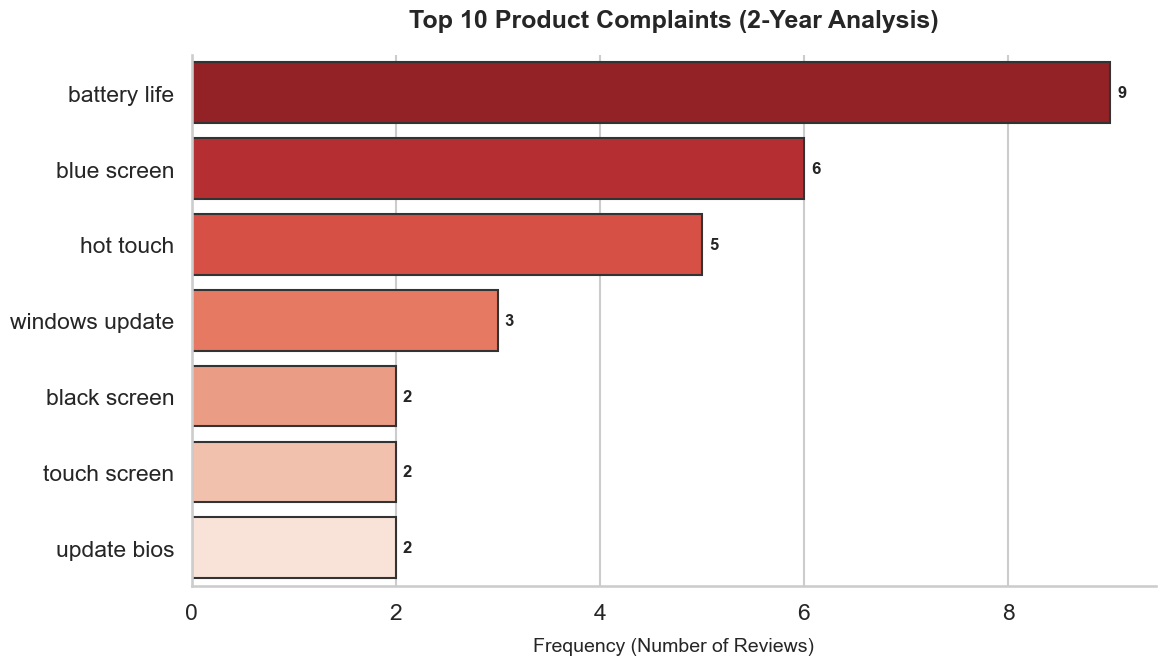

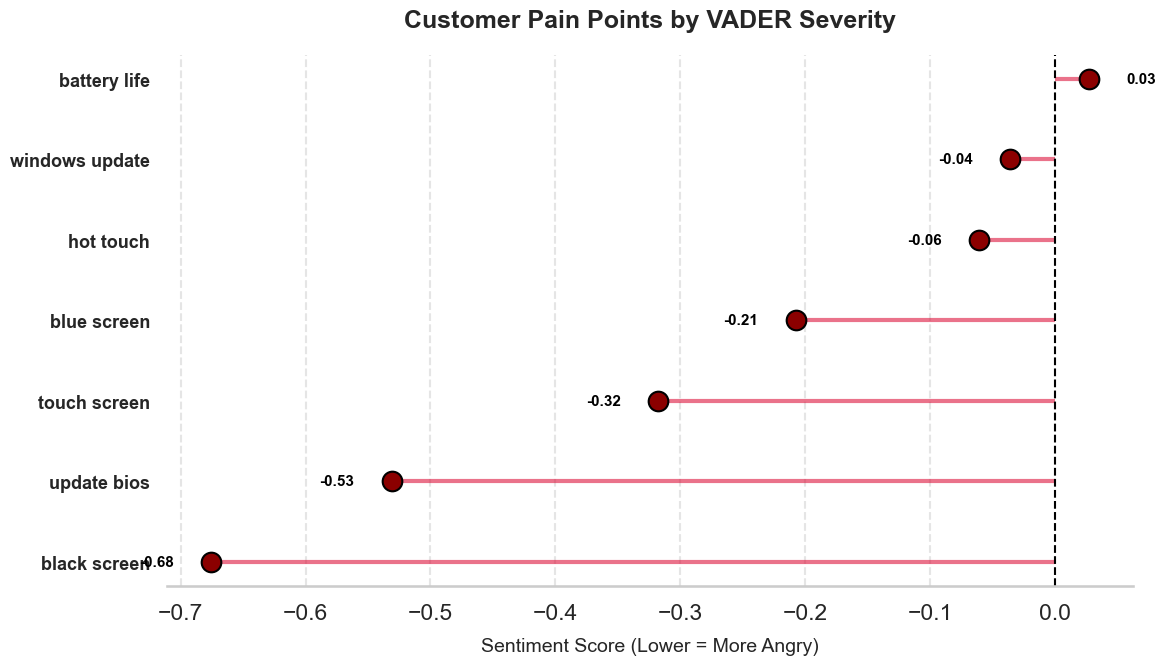

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer

# ==========================================
# STEP 0: LOAD & CLEAN DATA
# ==========================================
# Ensure the filename matches the file in your local directory
df = pd.read_csv("FusionTech_Translated_Dataset.csv")
# Remove duplicate reviews
df = df.drop_duplicates(subset=['text'])

# Convert timestamps to standard datetime
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')

# Calculate the 2-year (24 month) window
max_date = df['datetime'].max()
start_date = (max_date - pd.DateOffset(months=23)).replace(day=1)

# Filter by date and drop missing text
df = df[(df['datetime'] >= start_date) & (df['datetime'] <= max_date)].copy()
df = df.dropna(subset=['text']).reset_index(drop=True)

# Isolate negative reviews (1 and 2 stars)
df_neg = df[df['rating'] <= 2].copy()

# ==========================================
# STEP 1: VADER SENTIMENT SCORING
# ==========================================
# VADER is excellent at reading exclamation marks, all-caps, and social media text
analyzer = SentimentIntensityAnalyzer()

# We extract the 'compound' score which ranges from -1 (most negative) to 1 (most positive)
df_neg['sentiment_score'] = df_neg['text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

# ==========================================
# STEP 2: AGGRESSIVE TEXT CLEANING
# ==========================================
# Expanded stop words to eliminate non-diagnostic tech words and user actions
stop_words_list = [
    "i","me","my","we","our","you","your","he","him","she","her","it","they","them",
    "what","which","who","this","that","these","those","am","is","are","was","were",
    "be","been","have","has","had","do","does","did","a","an","the","and","but","if",
    "or","because","as","until","while","of","at","by","for","with","about","against",
    "into","through","during","before","after","above","below","to","from","up","down",
    "in","out","on","off","over","under","again","then","once","here","there","when",
    "where","why","how","all","any","both","each","few","more","most","other","some",
    "such","no","nor","not","only","own","same","so","than","too","very","can","will",
    "just","don","should","now",
    "laptop","computer","fusiontech","dell","buy","bought","get","got","one",
    "would","use","im","like","really","good","great","well","even","much",
    "also","dont","cant","didnt","ive","product", "fast","faster","quick","quicker",
    "speed","performance", "brand","new","time","week","day",
    "stay", "away", "google", "search", "amazon", "sent", "back", "return", "returned",
    "money", "waste", "tried", "trying", "work", "working", "works", "fix", "fixed",
    "customer", "service", "support", "call", "called", "told", "said", "say", 
    "month", "months", "days", "hours", "year", "years", "pc", "device", "machine", 
    "buy", "buying", "purchased", "purchase", "gb", "tb", "ram", "ssd", "known", 
    "message", "know", 
    # --- ADDED TO BAN GENERIC COMPLAINTS ---
    "issue", "issues", "problem", "problems", "error", "errors", "defect", "defects",
    "unacceptable", "took", "terrible", "awful", "bad", "worst", "horrible"
]

def clean_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()
    words = text.split()
    return " ".join([w for w in words if w not in stop_words_list])

df_neg['cleaned_review'] = df_neg['text'].apply(clean_text)

# ==========================================
# STEP 3: PHRASE EXTRACTION (N-GRAMS)
# ==========================================
vectorizer = CountVectorizer(
    ngram_range=(2, 3), # Look for 2 to 3 word phrases
    max_features=250,   # Cast a wide net initially
    min_df=2            # Phrase must appear in at least 2 reviews
)

X = vectorizer.fit_transform(df_neg['cleaned_review'])
phrases = vectorizer.get_feature_names_out()

# ==========================================
# STEP 4: BUILD METRICS
# ==========================================
phrase_data = []
for phrase in phrases:
    mask = df_neg['cleaned_review'].str.contains(phrase, regex=False)
    matching_reviews = df_neg[mask]
    count = len(matching_reviews)
    
    # Calculate average VADER compound score for this specific phrase
    avg_sentiment = matching_reviews['sentiment_score'].mean()
    
    # Keep if the context leans negative or neutral (VADER score < 0.05)
    if avg_sentiment < 0.05:
        phrase_data.append({
            'Phrase': phrase,
            'Frequency': count,
            'Severity': avg_sentiment
        })

df_phrases = pd.DataFrame(phrase_data)

# ==========================================
# STEP 5: STRICT PROBLEM-FOCUSED FILTER
# ==========================================
# Explicitly define the hardware, software, and physical components we care about
problem_keywords = [
    # Specific Symptoms
    "overheat", "crash", "freeze", "lag", "slow", "broken",
    "drain", "noise", "hot", "damage", "warm", "heat", "break", "crack", "scratch",
    
    # Specific Hardware / Components
    "screen", "keyboard", "battery", "charge", "power", "fan", 
    "blue", "bsod", "boot", "start", "turn", "wifi", 
    "connection", "internet", "bluetooth", "audio", "sound", 
    "speaker", "mic", "camera", "webcam", "key", "pad", "trackpad", 
    "touchpad", "mouse", "case", "hinge", "motherboard", "drive", "disk", "cooling",
    
    # Specific Software
    "update", "window", "bios", "windows"
]

# Require an exact match of at least one word from the problem list
if not df_phrases.empty:
    df_phrases = df_phrases[
        df_phrases['Phrase'].apply(
            lambda x: any(k in x.split() for k in problem_keywords) 
        )
    ]

# ==========================================
# STEP 6: TOP 10 COMPLAINTS
# ==========================================
if not df_phrases.empty:
    df_phrases = (
        df_phrases
        .sort_values(by='Frequency', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    print("\n--- TOP 10 HARDWARE/SOFTWARE ISSUES ---")
    print(df_phrases)
# ==========================================
# STEP 7: VISUALIZATION (Aesthetic Upgrade)
# ==========================================
# 1. Set a modern, clean default theme
sns.set_theme(style="whitegrid", context="talk")

# ------------------------------------------
# 7A: Frequency Bar Chart
# ------------------------------------------
plt.figure(figsize=(12, 7))

# Use a gradient red palette and add a subtle border to the bars
ax = sns.barplot(
    data=df_phrases.sort_values('Frequency', ascending=False), 
    x='Frequency', 
    y='Phrase', 
    palette='Reds_r', 
    edgecolor='.2'
)

plt.title('Top 10 Product Complaints (2-Year Analysis)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Frequency (Number of Reviews)', fontsize=14, labelpad=10)
plt.ylabel('') # Remove the redundant 'Phrase' label

# Clean up borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Automatically add the exact number to the end of each bar
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ------------------------------------------
# 7B: Severity Lollipop Chart (Replaces Scatter)
# ------------------------------------------
plt.figure(figsize=(12, 7))

# Sort so the worst (most negative) severity is at the bottom
df_plot = df_phrases.sort_values(by='Severity', ascending=True)

# Create the "sticks" of the lollipop
plt.hlines(
    y=range(len(df_plot)), 
    xmin=0, 
    xmax=df_plot['Severity'], 
    color='crimson', 
    alpha=0.6, 
    linewidth=3
)

# Create the "candy" (dots) at the end of the sticks
plt.scatter(
    df_plot['Severity'], 
    range(len(df_plot)), 
    s=200, 
    color='darkred', 
    edgecolor='black', 
    zorder=3
)

# Add numeric text cleanly offset from the dot
for i, (_, row) in enumerate(df_plot.iterrows()):
    # Push text slightly left if negative, slightly right if positive
    offset = -0.03 if row['Severity'] < 0 else 0.03
    align = 'right' if row['Severity'] < 0 else 'left'
    
    plt.text(
        row['Severity'] + offset, 
        i, 
        f"{row['Severity']:.2f}", 
        va='center', 
        ha=align, 
        fontsize=11, 
        fontweight='bold', 
        color='black'
    )

# Format the Y-axis to clearly show the phrase names
plt.yticks(range(len(df_plot)), df_plot['Phrase'], fontsize=13, fontweight='bold')

plt.title('Customer Pain Points by VADER Severity', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Sentiment Score (Lower = More Angry)', fontsize=14, labelpad=10)

# Add a strong reference line at 0.0
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

# Clean up background grid and borders
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.grid(axis='y', visible=False) # Remove horizontal lines through text
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.tight_layout()
plt.show()